In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sklearn

from FantAIno.constants import (
    S3_EMBEDDINGS_TABLE_BUCKET_NAME,
    S3_EMBEDDINGS_DATABASE_NAME,
    S3_SMALL_EMBEDDINGS_TABLE,
    S3_LARGE_EMBEDDINGS_TABLE,
)
from FantAIno.utils.data_utils import get_secret
from FantAIno.utils.s3_utils import retrieve_s3_table_catalog

## Useful Embeddings

In the previous embeddings demo, we showed that albums can have similar embeddings structures to one another. The heatmaps of these embeddings that we observed earlier also indicate something important to consider. Not all embedding dimesnions have a high magnitude signal. If we were to chuck in a large embedding vector as part of our feature set, we might be adding 3072 features when only a small fraction of them are useful for our purposes. This creates a very noisy input and can make our large models much harder to train. Therefore, let's employ some dimensionality reduction techniques here.

In [2]:
embeddings_catalog_name = S3_EMBEDDINGS_TABLE_BUCKET_NAME
account_id = get_secret("AWS_ACCOUNT_ID")
s3tablebucketname = S3_EMBEDDINGS_TABLE_BUCKET_NAME
region = get_secret("PYICEBERG_AWS_DEFAULT_REGION")

In [3]:
# Retrieve the S3 embeddings table catalog
embeddings_catalog = retrieve_s3_table_catalog(
    catalog_name=embeddings_catalog_name,
    account_id=account_id,
    s3tablebucketname=s3tablebucketname,
    region=region,
)

# Specify the database and table name for embeddings
small_embeddings_table = embeddings_catalog.load_table(f"{S3_EMBEDDINGS_DATABASE_NAME}.{S3_SMALL_EMBEDDINGS_TABLE}")

# Scan all records in the embeddings table and convert to Pandas DataFrame
all_records_arrow = small_embeddings_table.scan().to_arrow()
embeddings_pd = all_records_arrow.to_pandas()

In [4]:
embeddings_pd.head()

,artist_name,album_name,embedding_dim_0,embedding_dim_1,embedding_dim_2,embedding_dim_3,embedding_dim_4,embedding_dim_5,embedding_dim_6,embedding_dim_7,...,embedding_dim_1526,embedding_dim_1527,embedding_dim_1528,embedding_dim_1529,embedding_dim_1530,embedding_dim_1531,embedding_dim_1532,embedding_dim_1533,embedding_dim_1534,embedding_dim_1535
0,Little Women,Throat,0.015394,-0.034816,-0.009337,0.014463,0.007346,0.014379,-0.052330,0.049218,...,-0.008628,0.020673,0.002599,-0.002842,-0.021771,0.024914,0.024990,-0.013571,0.017728,0.018995
1,Liars,Sisterworld,0.065212,0.002245,0.001368,-0.005359,-0.017730,-0.001474,0.015335,0.008444,...,-0.011120,0.019572,0.015522,0.000152,0.005141,0.031342,0.012049,0.010969,0.007874,-0.013536
2,Portugal. The Man,American Ghetto,0.027352,-0.017791,-0.001627,-0.011750,0.002927,-0.011369,0.015577,0.010501,...,-0.013507,0.020381,0.022981,-0.014747,0.017607,0.028279,0.026924,0.014427,0.013446,-0.008307
3,Melvins,The Bride Screamed Murder,0.042054,-0.009212,0.009545,-0.026684,-0.040211,-0.010451,0.006789,-0.004239,...,-0.002544,0.026654,0.009443,-0.004480,-0.007582,0.051764,-0.005747,0.013047,-0.003901,-0.000847
4,Ariel Pinks Haunted Graffiti,Before Today,0.042316,-0.023333,-0.011047,-0.013707,-0.012073,-0.007131,0.009405,-0.010254,...,-0.030219,0.017938,0.003135,0.003345,-0.000323,0.029928,0.011024,0.019071,0.008934,-0.009208


In [5]:
embeddings_pd.shape

(3120, 1538)

In [6]:
embeddings_pd = embeddings_pd.dropna()
embeddings_pd.shape

(3117, 1538)

In [7]:
pca = sklearn.decomposition.PCA(n_components=100)
X = pca.fit_transform(embeddings_pd.select_dtypes(include=[np.number]))

In [8]:
X

array([[ 1.01612964e+00, -1.21704054e-01, -7.79831795e-02, ...,
         1.24460249e-03,  4.87709283e-04, -5.01615442e-04],
       [-9.12429534e-02,  2.20011611e-01,  9.63625047e-02, ...,
        -1.37502983e-02, -1.84322486e-02,  5.37806972e-03],
       [-6.66043661e-02,  8.96068092e-02, -7.29653695e-02, ...,
         2.32090515e-02, -2.11972922e-02,  9.64126127e-03],
       ...,
       [-1.21679553e-01,  6.27476351e-02, -2.02046119e-01, ...,
        -1.56184713e-02,  8.02595379e-03, -1.96171302e-03],
       [ 6.93295155e-01, -1.63331938e-03, -1.98317103e-02, ...,
         2.32643735e-03, -1.34814596e-02,  1.77296509e-02],
       [ 3.45956006e-01, -1.22944877e-02, -1.06061163e-01, ...,
         1.03412617e-02,  3.54073507e-03,  3.60573167e-03]],
      shape=(3117, 100))

Text(0.5, 1.0, 'Proportion of Variance Explained by Each Principal Component')

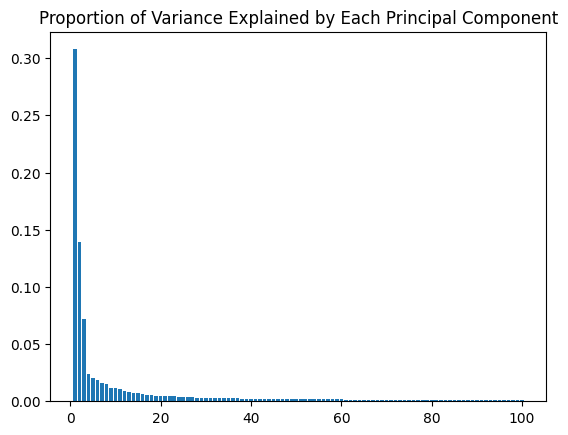

In [ ]:
plt.bar(x=range(1, len(pca.explained_variance_ratio_)+1), height=pca.explained_variance_ratio_)
plt.title("Proportion of Variance Explained by Each Principal Component")

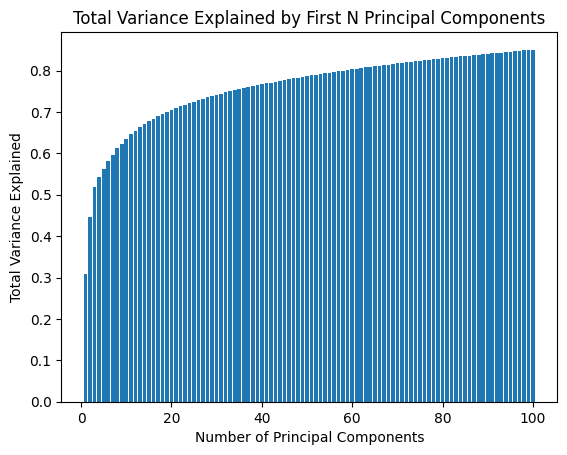

In [ ]:
pca_cumsum = pca.explained_variance_ratio_.cumsum()

plt.bar(x=range(1, len(pca_cumsum)+1), height=pca_cumsum)
plt.title("Total Variance Explained by First N Principal Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Total Variance Explained")
plt.show()

In [30]:
pca_cumsum[-1].item()

0.8504484139916619

With principal components analysis (PCA) ALONE - aka the most obvious dimension reductionality technique known in data science - we have shown that about 85% of total variation in the embeddings can be explained by 100 principal components. Therefore, we can find some dimensionality reduction technique (either PCA or something more sophisticated) to reduce the number of predictors we need to accurately predict an album using its lyrics.